In [84]:
import pandas as pd

In [85]:
df = pd.read_csv('workshop_car_service_dataset.csv')

In [86]:
df.head()

,car_name,car_age_years,mileage_km,service_type,parts_to_replace,workload_queue,mechanic_experience_years,condition_of_vehicle,availability_of_spare_parts,engine_type,engine_capacity_cc,num_cylinders,turbocharged,battery_kwh,oil_quality_score,check_engine_light,avg_engine_temp_c,last_service_months_ago,engine_wear_score,service_time_hours
0,Kia Carens,14,230253,Electrical,2,0,5,Good,Not Available,Petrol,1459,4,False,NaN,4.07,True,96.1,18,94.7,19.32
1,Toyota Glanza,3,90282,Full,4,0,8,Poor,Available,Petrol,1613,4,False,NaN,6.01,False,93.3,23,39.4,15.53
2,Kia Carens,8,179583,Full,1,3,21,Good,Available,Petrol,1265,4,True,NaN,4.98,False,90.7,5,63.0,10.38
3,Honda City,14,19337,Engine Repair,2,2,20,Average,Available,Petrol,1604,4,False,NaN,6.05,True,95.4,3,41.1,15.05
4,Maruti Suzuki Celerio,13,198725,Basic,2,1,1,Average,Available,Petrol,1519,4,False,NaN,4.31,False,90.9,2,73.2,10.86


In [87]:
df.shape

(800, 20)

In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   car_name                     800 non-null    object 
 1   car_age_years                800 non-null    int64  
 2   mileage_km                   800 non-null    int64  
 3   service_type                 800 non-null    object 
 4   parts_to_replace             800 non-null    int64  
 5   workload_queue               800 non-null    int64  
 6   mechanic_experience_years    800 non-null    int64  
 7   condition_of_vehicle         800 non-null    object 
 8   availability_of_spare_parts  800 non-null    object 
 9   engine_type                  800 non-null    object 
 10  engine_capacity_cc           800 non-null    int64  
 11  num_cylinders                800 non-null    int64  
 12  turbocharged                 800 non-null    bool   
 13  battery_kwh         

In [89]:
df.isna().sum()

car_name                         0
car_age_years                    0
mileage_km                       0
service_type                     0
parts_to_replace                 0
workload_queue                   0
mechanic_experience_years        0
condition_of_vehicle             0
availability_of_spare_parts      0
engine_type                      0
engine_capacity_cc               0
num_cylinders                    0
turbocharged                     0
battery_kwh                    760
oil_quality_score                0
check_engine_light               0
avg_engine_temp_c                0
last_service_months_ago          0
engine_wear_score                0
service_time_hours               0
dtype: int64

In [90]:
df['battery_kwh'] = df['battery_kwh'].fillna(0)

In [91]:
df['car_name'].tolist()

['Kia Carens',
 'Toyota Glanza',
 'Kia Carens',
 'Honda City',
 'Maruti Suzuki Celerio',
 'Toyota Urban Cruiser',
 'Honda City',
 'Volkswagen Polo',
 'Mahindra Bolero',
 'Skoda Slavia',
 'Tata Altroz',
 'Honda Jazz',
 'Volkswagen Vento',
 'Skoda Slavia',
 'Mahindra Thar',
 'Skoda Slavia',
 'Mahindra Scorpio',
 'Toyota Innova',
 'Maruti Suzuki Swift',
 'Maruti Suzuki Celerio',
 'Skoda Kushaq',
 'Ford Figo',
 'Toyota Fortuner',
 'Toyota Innova',
 'Tata Tiago',
 'Maruti Suzuki Swift',
 'Kia Seltos',
 'Volkswagen Vento',
 'Tata Harrier',
 'Ford Endeavour',
 'Honda Amaze',
 'Ford Aspire',
 'Skoda Kushaq',
 'Honda WR-V',
 'Skoda Slavia',
 'Kia Seltos',
 'Kia Carnival',
 'Kia Carnival',
 'Tata Harrier',
 'Hyundai Creta',
 'Mahindra XUV700',
 'Kia Seltos',
 'Toyota Fortuner',
 'Skoda Slavia',
 'Hyundai Venue',
 'Ford Ecosport',
 'Honda WR-V',
 'Tata Nexon',
 'Honda WR-V',
 'Ford Figo',
 'Mahindra XUV700',
 'Toyota Glanza',
 'Tata Harrier',
 'Volkswagen Polo',
 'Volkswagen Taigun',
 'Skoda Kush

In [92]:
df['car_name'].nunique()

38

In [93]:
df.duplicated().sum()

0

### Enocding car name using OHE

In [96]:
from sklearn.preprocessing import OneHotEncoder
encoder_car = OneHotEncoder(handle_unknown='ignore',sparse_output=False)
X_car = encoder_car.fit_transform(df[['car_name']])

In [58]:
X_car

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [98]:
import joblib
joblib.dump(encoder_car, 'model/car_name_encoder.pkl')

['model/car_name_encoder.pkl']

### Encoding of Service type

In [100]:
df['service_type'].value_counts()

service_type
Basic            282
Full             211
Engine Repair    114
Transmission      80
Electrical        79
Painting          34
Name: count, dtype: int64

In [101]:
encoder_service = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_service = encoder_service.fit_transform(df[['service_type']])

In [102]:
#Save this model
joblib.dump(encoder_service, "model/service_type_encoder.pkl")

['model/service_type_encoder.pkl']

### condition of vehicle

In [103]:
df['condition_of_vehicle'].unique()

array(['Good', 'Poor', 'Average'], dtype=object)

In [104]:
df['condition_of_vehicle'] = df['condition_of_vehicle'].map({'Poor': 0,'Average': 1,'Good': 2})

### availability_of_spare_parts

In [105]:
df['availability_of_spare_parts'].unique() 

array(['Not Available', 'Available', 'Limited'], dtype=object)

In [106]:
# Available → Limited → Not Available
df['availability_of_spare_parts'] = df['availability_of_spare_parts'].map({'Not Available': 0,'Limited': 1,'Available': 2})

### OHE for Engine type

In [107]:
encoder_engine = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_engine = encoder_engine.fit_transform(df[['engine_type']])

In [108]:
joblib.dump(encoder_engine, "model/engine_type_encoder.pkl")

['model/engine_type_encoder.pkl']

# Feature Selection

In [109]:
df.head()

,car_name,car_age_years,mileage_km,service_type,parts_to_replace,workload_queue,mechanic_experience_years,condition_of_vehicle,availability_of_spare_parts,engine_type,engine_capacity_cc,num_cylinders,turbocharged,battery_kwh,oil_quality_score,check_engine_light,avg_engine_temp_c,last_service_months_ago,engine_wear_score,service_time_hours
0,Kia Carens,14,230253,Electrical,2,0,5,2,0,Petrol,1459,4,False,0.0,4.07,True,96.1,18,94.7,19.32
1,Toyota Glanza,3,90282,Full,4,0,8,0,2,Petrol,1613,4,False,0.0,6.01,False,93.3,23,39.4,15.53
2,Kia Carens,8,179583,Full,1,3,21,2,2,Petrol,1265,4,True,0.0,4.98,False,90.7,5,63.0,10.38
3,Honda City,14,19337,Engine Repair,2,2,20,1,2,Petrol,1604,4,False,0.0,6.05,True,95.4,3,41.1,15.05
4,Maruti Suzuki Celerio,13,198725,Basic,2,1,1,1,2,Petrol,1519,4,False,0.0,4.31,False,90.9,2,73.2,10.86


In [110]:
df = df.drop(columns=['car_name', 'service_type', 'engine_type'])

In [111]:
X_df = df.drop(columns=['service_time_hours'])

In [112]:
X_df.columns

Index(['car_age_years', 'mileage_km', 'parts_to_replace', 'workload_queue',
       'mechanic_experience_years', 'condition_of_vehicle',
       'availability_of_spare_parts', 'engine_capacity_cc', 'num_cylinders',
       'turbocharged', 'battery_kwh', 'oil_quality_score',
       'check_engine_light', 'avg_engine_temp_c', 'last_service_months_ago',
       'engine_wear_score'],
      dtype='object')

In [113]:
import numpy as np

# Combine: numeric/mapped columns + encoded features
X = np.concatenate([X_df.values, X_car, X_service, X_engine], axis=1)

In [114]:
y = df['service_time_hours']

In [115]:
X.shape

(800, 64)

In [116]:
y.shape

(800,)

# Model Training

In [117]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [118]:
X_train.shape,X_test.shape, y_train.shape, y_test.shape

((640, 64), (160, 64), (640,), (160,))

In [119]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [120]:
y_pred = model.predict(X_test)

# Performance Metrics

In [121]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("📈 Linear Regression Performance:")
print(f"MAE  : {mae:.2f} hours")
print(f"MSE : {mse:.2f} hours")
print(f"R² Score: {r2:.3f}")

📈 Linear Regression Performance:
MAE  : 2.75 hours
MSE : 16.81 hours
R² Score: 0.895


### Saving Training model

In [122]:
joblib.dump(model, "model/service_model.pkl")

['model/service_model.pkl']

Text(0.5, 1.0, 'Actual vs Predicted Service Time - Linear Regression')

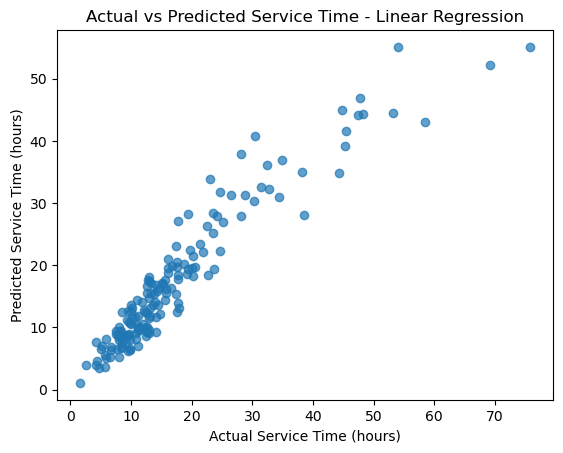

In [123]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Actual Service Time (hours)")
plt.ylabel("Predicted Service Time (hours)")
plt.title("Actual vs Predicted Service Time - Linear Regression")

In [126]:
print("Model expects:", model.n_features_in_, "features.")

Model expects: 64 features.


In [127]:
print(len(encoder_car.get_feature_names_out(['car_name'])))
print(len(encoder_service.get_feature_names_out(['service_type'])))
print(len(encoder_engine.get_feature_names_out(['engine_type'])))

38
6
4
